# Sleep Health Correlation Notebook
## Notebook Summary

This project explores the relationship between total activity levels and self-reported stress across different occupations. The goal was to identify whether higher activity is associated with increased stress and whether occupation plays a meaningful role in that relationship.

The analysis includes:

- Data cleaning and occupation-level filtering
- Exploratory data analysis (EDA)
- Correlation analysis
- K-means clustering to identify patterns in activity and stress

## Import Dependencies

In [105]:
!pip install kagglehub~=0.4.2 pandas~=3.0.0 plt~=0.2.0 seaborn~=0.13.2 matplotlib~=3.10.8 scikit-learn~=1.8.0  -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [106]:
import pandas as pd
import kagglehub
import plt
import seaborn as sns
import shutil
import os

## Load Data

In [107]:
DATA_DIR="data"
IMG_DIR="images"
# Create the data directory if it doesn't exist
os.makedirs("data", exist_ok=True)
os.makedirs("images", exist_ok=True)
# Download dataset from kagglehub
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset",
                                  "Sleep_health_and_lifestyle_dataset.csv")

## Data Summary

In [108]:
# Copy file to the data directory
destination = DATA_DIR+"/Sleep_health_and_lifestyle_dataset.csv"
shutil.copy(path, destination)
print(f"Dataset copied to {destination}")
df = pd.read_csv(DATA_DIR+"/Sleep_health_and_lifestyle_dataset.csv")
df.drop("Person ID", axis=1, inplace=True)
df.head()

Dataset copied to data/Sleep_health_and_lifestyle_dataset.csv


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# Notebook EDA
## Original Occupation List

In [109]:
df_copy = df.copy()
categorical_columns = df_copy.columns[df_copy.dtypes == 'str']

# Deleting lawyer data in both  original data and due to insufficient data.
occupation_stress = df.groupby('Occupation')['Stress Level'].describe()
print("\nStress Level by Occupation:")
occupation_stress.head(10)


Stress Level by Occupation:


,count,mean,std,min,25%,50%,75%,max
Occupation,,,,,,,,
Accountant,37.0,4.594595,1.235122,3.0,4.0,4.0,4.0,7.0
Doctor,71.0,6.732394,1.372773,3.0,6.0,6.0,8.0,8.0
Engineer,63.0,3.888889,1.137500,3.0,3.0,3.0,5.0,7.0
Lawyer,47.0,5.063830,0.247092,5.0,5.0,5.0,5.0,6.0
Manager,1.0,5.000000,NaN,5.0,5.0,5.0,5.0,5.0
Nurse,73.0,5.547945,2.392355,3.0,3.0,6.0,8.0,8.0
Sales Representative,2.0,8.000000,0.000000,8.0,8.0,8.0,8.0,8.0
Salesperson,32.0,7.000000,0.000000,7.0,7.0,7.0,7.0,7.0
Scientist,4.0,7.000000,1.154701,6.0,6.0,7.0,8.0,8.0


## Data Cleaning

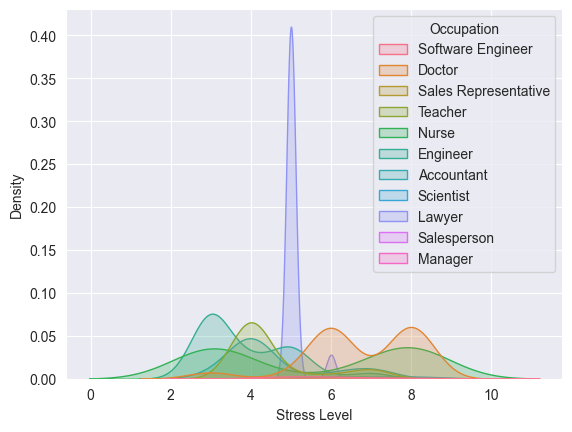

In [110]:
sns.kdeplot(data=df, x="Stress Level", hue="Occupation", fill=True, warn_singular=False);

### Removing Occupations
- I'm removing the Manager and Sales Representative occupation from the dataset due to a low sample count
- I'm removing Lawyer and Salesperson due to having a standard deviation of 0 which likely indicates the data is synthetic.
- I'm saving the Sales Representative data to a new data frame because it's usefulness is borderline.

In [111]:
removed_occupations = ['Lawyer', 'Manager', 'Salesperson', 'Sales Representative']
df_copy = df.copy()
df_clean = df[~df['Occupation'].isin(removed_occupations)]

## Categorial Column Charts
### Occupation vs. Stress

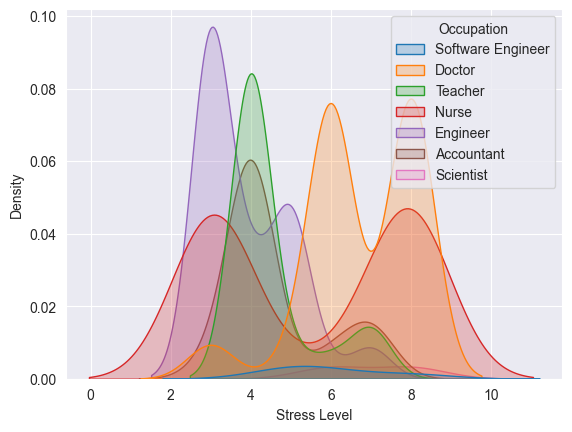

In [112]:
### Deleting outliers from dataset.
df_copy = df_clean.copy()
sns.kdeplot(data=df_copy, x="Stress Level", hue="Occupation", fill=True, warn_singular=False);


#### Observations
- Occupation vs stress chart looks a lot cleaner after outliers are removed.

In [113]:
## Categorical Columns
categorical_columns = df.select_dtypes(include=['str']).columns
df[categorical_columns].describe()

,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


### Sleep Disorders vs. Stress

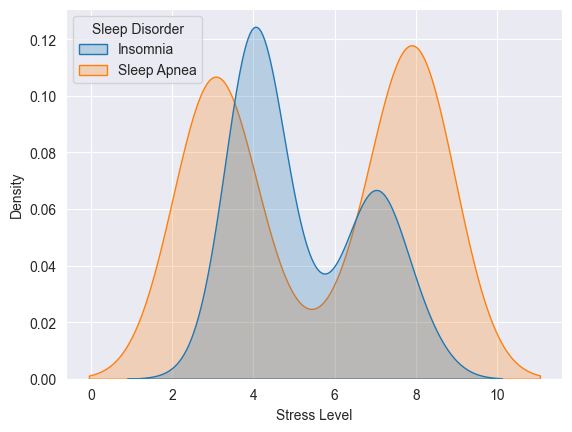

In [114]:
sns.kdeplot(data=df_copy, x="Stress Level", hue="Sleep Disorder", fill=True, warn_singular=False);

#### Observations
- The correlation between insomnia and stress is clearly visible but not as pronounced as expected.
- The correlation between sleep apnea and stress is even weeker
- There is a gap in our data around stress around 5 which I assume caused by reporting bias.

### Gender vs. Stress

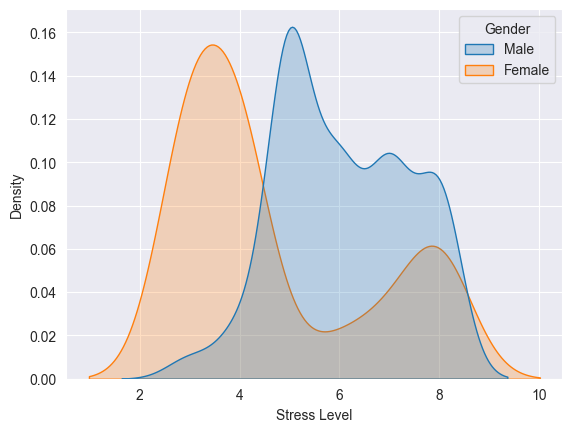

In [115]:
sns.kdeplot(data=df, x="Stress Level", hue="Gender", fill=True, warn_singular=False);

#### Observation
- On Average men seem to have a higher stress level than women

## Data Conversion
- Converting categorical variables to numerical ones

In [116]:
# Gender Conversion:
df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})
# The blood pressure conversion
df_clean['BP_Systolic'] = df_clean['Blood Pressure'].str.split('/').str[0]
df_clean['BP_Diastolic'] = df_clean['Blood Pressure'].str.split('/').str[1]
df_clean['BP_Systolic'] = pd.to_numeric(df_clean['BP_Systolic'])
df_clean['BP_Diastolic'] = pd.to_numeric(df_clean['BP_Diastolic'])
df_clean.drop("Blood Pressure", axis=1, inplace=True)
# BMI conversion
df_clean['BMI_Numerical'] = df_clean['BMI Category'].map({
    'Normal': (18.5 + 24.9 )/2,
    'Normal Weight': (18.5 + 24.9 )/2,
    'Overweight': (25 + 29.9 )/2,
    'Obese': (30 + 34.9 )/2
})
df_clean.to_csv("data/clean_data.csv", index=False)
print("Data Cleaned Successfully")
numerical_columns = df_clean.select_dtypes(include=['number']).columns
df_clean[numerical_columns].describe()


Data Cleaned Successfully


## Numerical Correlation Charts

### Sleep Quality Correlation Chart

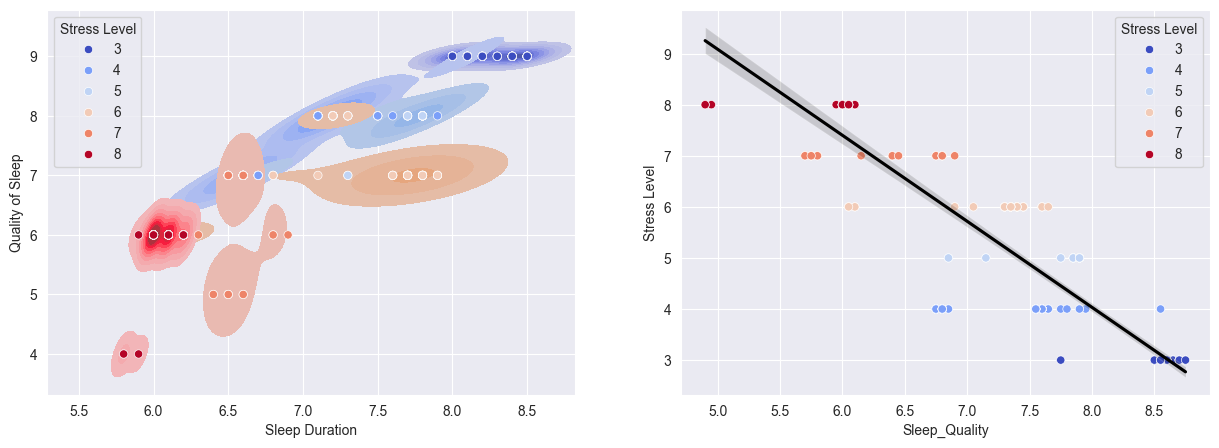

In [119]:
from matplotlib import pyplot as plt
df_agg = df_clean.copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.kdeplot(data=df_copy, x="Sleep Duration", y="Quality of Sleep", hue="Stress Level", fill=True, palette="coolwarm", ax=ax1)
sns.scatterplot(data=df_copy, x="Sleep Duration", y="Quality of Sleep", hue="Stress Level", palette="coolwarm", ax=ax1)

# Combining Sleep Duration and Quality of Sleep into a single metric
df_agg['Sleep_Quality'] = (df_clean['Quality of Sleep'] + df_clean['Sleep Duration']) / 2
scatter = sns.scatterplot(data=df_agg, x="Sleep_Quality", hue="Stress Level", y="Stress Level", palette="coolwarm", ax=ax2)
sns.regplot(data=df_agg, x="Sleep_Quality", y="Stress Level", scatter=False, color="black", ax=ax2);

plt.savefig(IMG_DIR+"/Sleep_Quality_Correlation.png")

#### Observations
- There is a strong negative correlation between sleep quality and stress level.
- In the left plot you can see that individuals with the highest stress level all rate their sleep duration and quality of sleep poorly.

### Heart Rate vs. Stress Level Correlation Chart

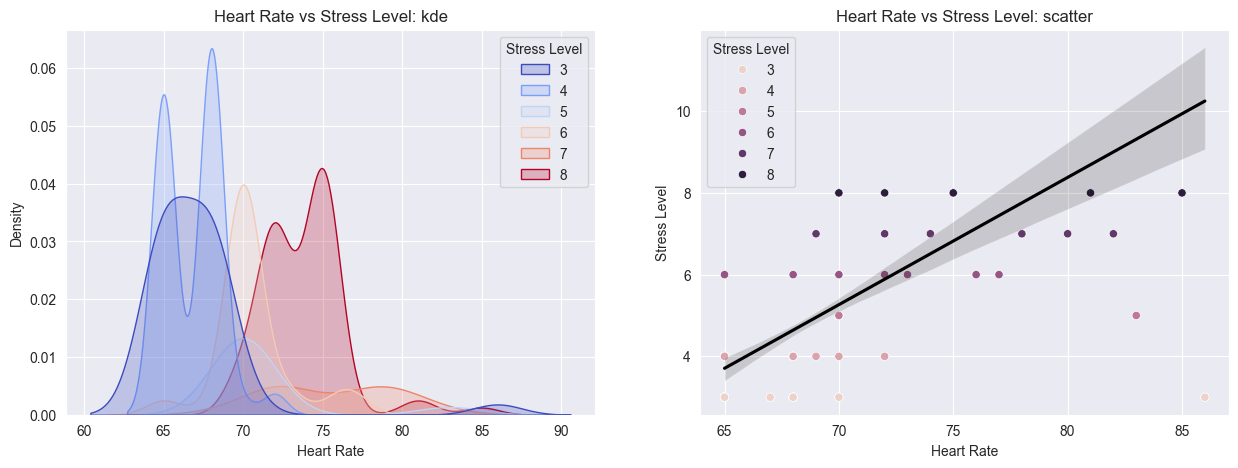

In [134]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(data=df_copy, x="Heart Rate", hue="Stress Level", fill=True, palette="coolwarm", ax=ax1)
ax1.set_title("Heart Rate vs Stress Level: kde")
ax2.set_title("Heart Rate vs Stress Level: Regression Plot")
sns.scatterplot(data=df_copy, x="Heart Rate", y="Stress Level", hue="Stress Level", ax=ax2)
sns.regplot(data=df_copy, x="Heart Rate", y="Stress Level", scatter=False, color="black", ax=ax2);

### Observation
- There is a clear correlation between heart rate and stress.

In [121]:
import matplotlib.pyplot as plt
def display_physical_activity_correlation(df_copy):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.set_title("Physical Activity Level vs Daily Steps")
    sns.kdeplot(data=df_copy, x="Physical Activity Level", y="Daily Steps", hue="Stress Level", fill=True,
                palette="coolwarm", ax=ax1)
    sns.kdeplot(data=df_copy, y="Daily Steps", hue="Physical Activity Level", x="Stress Level", fill=True,
                palette="coolwarm", warn_singular=False, ax=ax2)
    ax2.set_title("Daily Steps vs Physical Activity Level")
    plt.tight_layout()

### Physical Activity vs. Stress

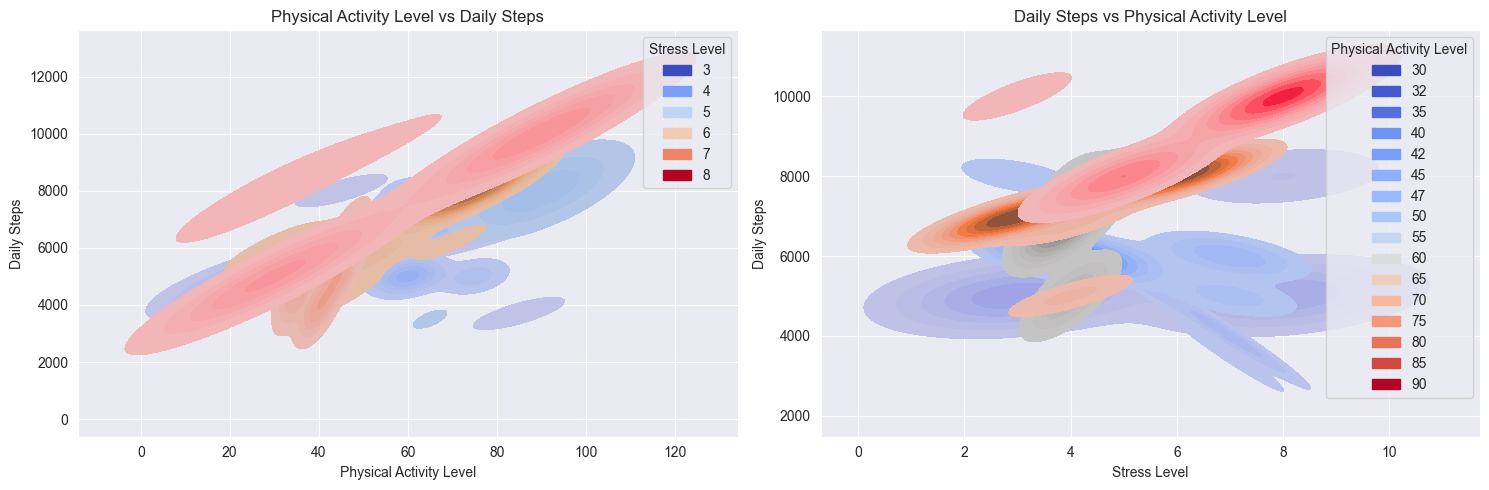

In [122]:
display_physical_activity_correlation(df_clean)

### Observations
- I see two clusters of high-stress individuals. One with a high step count and high physical activity level, and one with a low physical activity level and a medium step count.

## Data Correlation

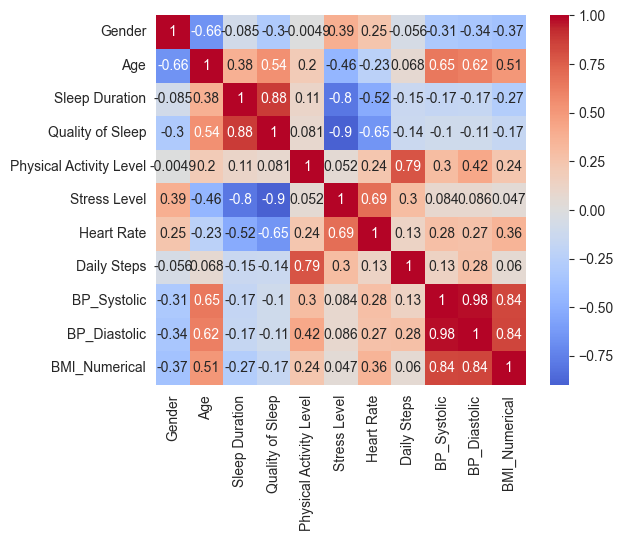

In [123]:
numerical_columns = df_clean.select_dtypes(include=['number']).columns
sns.heatmap(df_clean[numerical_columns].corr(), annot=True, cmap='coolwarm', center=0, square=True);

## EDA Summary
- Sleep quality is correlated with lower stress levels, lower BMI, and lower heart rate.
- Lower heart rate is highly correlated with lower stress levels.
- There was a correlation between physical activity and stress, but it wasn't consistent.

# Detailed Analysis

## Normalized Data

Index(['Gender', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps',
       'BP_Systolic', 'BP_Diastolic', 'BMI_Numerical'],
      dtype='str')


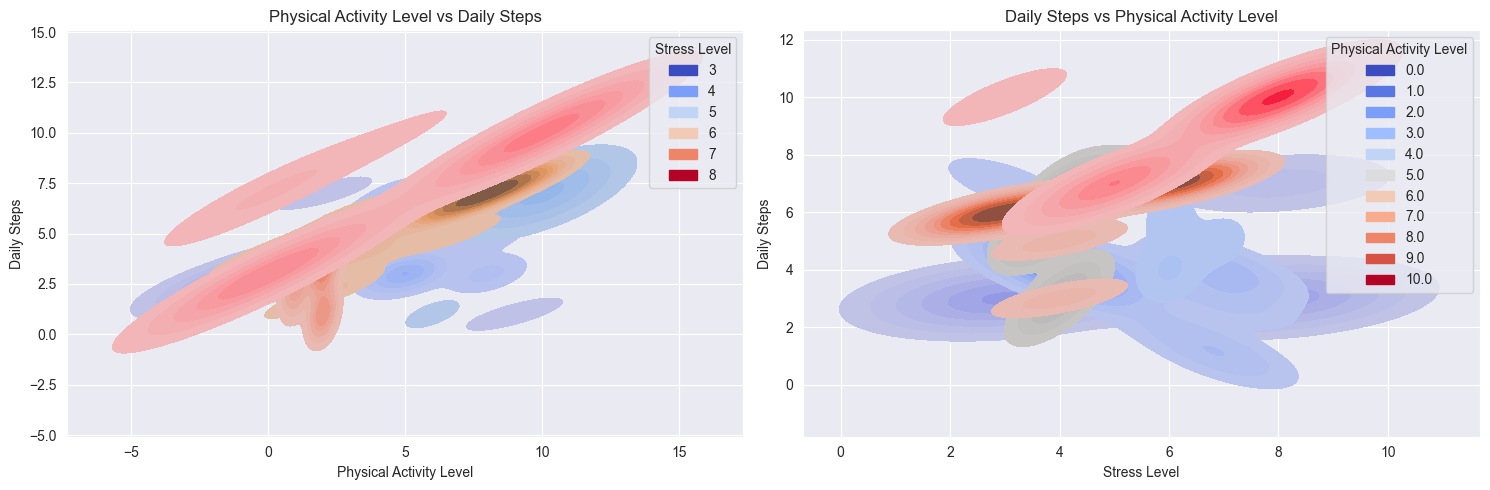

In [124]:
from sklearn.preprocessing import MinMaxScaler

def normalize_data(df_clean):
    numerical_columns = df_clean.select_dtypes(include=['number']).columns
    scaler = MinMaxScaler(feature_range=(0, 10))
    scaler_inverse = MinMaxScaler(feature_range=(0, 10))
    scaler_inverse.fit(df_clean[numerical_columns])

    df_clean[numerical_columns] = scaler.fit_transform(df_clean[numerical_columns])
    df_normalized = df_clean[numerical_columns]
    print(df_normalized.columns)

    # Using the original stress score to normalized_df since it's already between 1 and 10
    df_normalized['Stress Level'] = df_copy['Stress Level']
    ### Write clean data to csv file
    df_normalized = df_normalized.round(0)
    return df_normalized
df_normalized = normalize_data(df_clean)
display_physical_activity_correlation(df_normalized)

### Observations
- Physical Activity Levels plots look similar with normalized and non-normalized data.
## Total Activity Scatter Plot
- Creating combined feature from Physical Activity Level and Daily Steps

<Axes: xlabel='Total_Activity_Level', ylabel='Stress Level'>

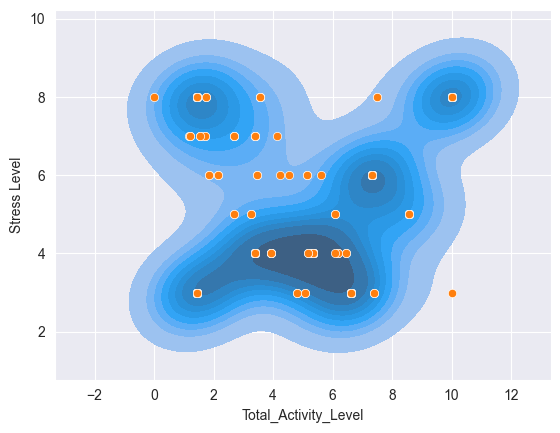

In [125]:
df_agg['Total_Activity_Level'] = (df_clean['Physical Activity Level'] + df_clean['Daily Steps']) / 2
sns.kdeplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", fill=True)
sns.scatterplot(data=df_agg, x="Total_Activity_Level", y="Stress Level");

### Physical Activity Clustering
- Creating clusters from physical activity level data

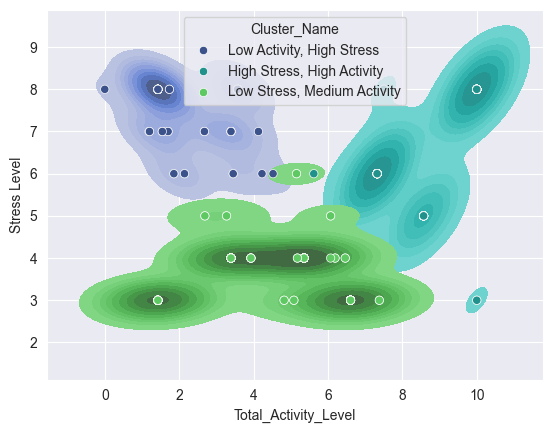

In [135]:
from sklearn.cluster import KMeans

physical_activity_cols = ['Physical Activity Level', 'Daily Steps', 'Stress Level']
df_clusters = df_clean[physical_activity_cols]
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(df_clusters)
df_agg['Cluster'] = kmeans.labels_
df_agg['Cluster_Name'] = df_agg['Cluster'].map(
    {0: 'Low Stress, Medium Activity', 1: 'High Stress, High Activity', 2: 'Low Activity, High Stress'})

# Create subplots

sns.kdeplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", hue="Cluster_Name", fill=True, palette="viridis")
sns.scatterplot(data=df_agg, x="Total_Activity_Level", y="Stress Level", hue="Cluster_Name", palette="viridis")
plt.savefig(IMG_DIR+"/Stress_Level_by_Cluster.png")


#### Observations
- Three clusters show up in the resulting data
     - Low Stress, Medium Activity
     - High Stress, Low Activity
     - High Stress, High Activity 
- I suspect the distinct clusters may be determined by whether someone's activity levels are related to their job or not.

Note: since the K-Means algorithm is not deterministic, I locked down the seed for this section.



### Cluster Regression Lines

Text(0.5, 1.0, 'Low Activity, High Stress')

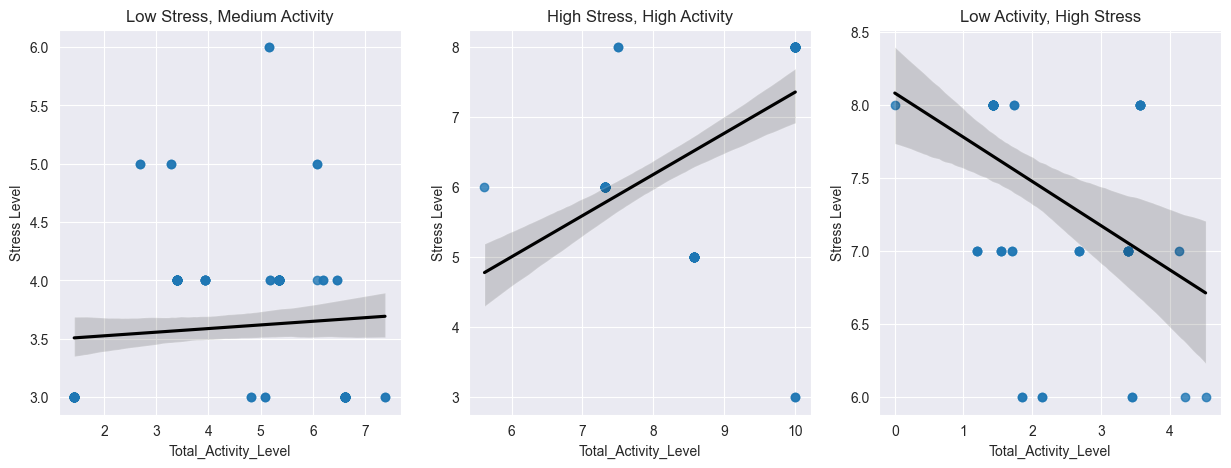

In [127]:
# Plotting regression line by cluster
cluster0 = df_agg[df_agg["Cluster_Name"] == "Low Stress, Medium Activity"]
cluster1 = df_agg[df_agg["Cluster_Name"] == "High Stress, High Activity"]
cluster2 = df_agg[df_agg["Cluster_Name"] == "Low Activity, High Stress"]
fix, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
sns.regplot(cluster0, x="Total_Activity_Level", y="Stress Level", ax=ax1, line_kws={"color": "black"})
ax1.set_title("Low Stress, Medium Activity")
sns.regplot(cluster1, x="Total_Activity_Level", y="Stress Level", ax=ax2, line_kws={"color": "black"})
ax2.set_title("High Stress, High Activity")
sns.regplot(cluster2, x="Total_Activity_Level", y="Stress Level", ax=ax3, line_kws={"color": "black"})
ax3.set_title("Low Activity, High Stress")


### Activity Levels by Occupation

Text(0.5, 1.0, 'Low Activity, High Stress')

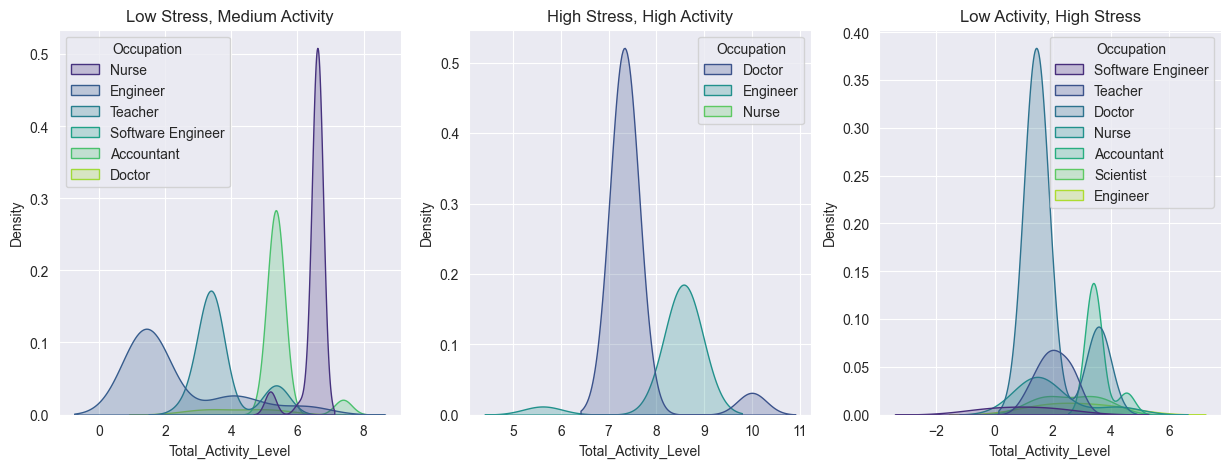

In [128]:
df_agg['Occupation'] = df_clean['Occupation']
# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
sns.kdeplot(cluster0, x="Total_Activity_Level", hue="Occupation", fill=True, palette="viridis", ax=ax1, warn_singular=False)
ax1.set_title("Low Stress, Medium Activity")
sns.kdeplot(cluster1, x="Total_Activity_Level", hue="Occupation", fill=True, palette="viridis", ax=ax2, warn_singular=False)
ax2.set_title("High Stress, High Activity")
sns.kdeplot(cluster2, x="Total_Activity_Level", hue="Occupation", fill=True, palette="viridis", ax=ax3, warn_singular=False)
ax3.set_title("Low Activity, High Stress")

#### Observation
- After plotting occupation and cluster on the same chart, it seems as if there are some occupations involve more total physical activity than others.
- A lot of the occupations show up in multiple categories, but there is enough information to split occupations into high-medium and low-activity occupations.

### Correlation Coefficient by Occupation

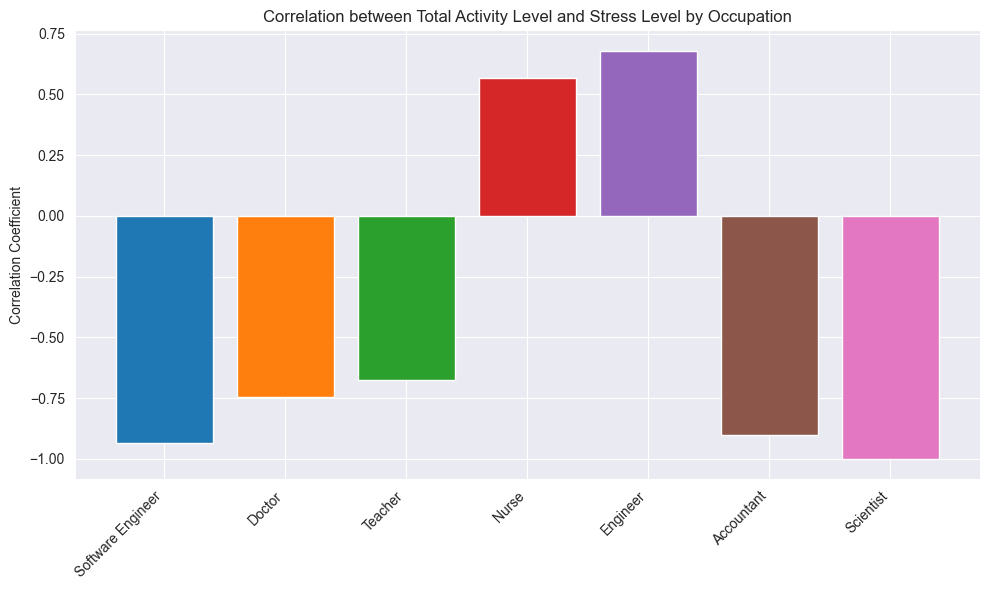

In [129]:
df_agg['Occupation'] = df_clean['Occupation']
occupation_list = df_agg['Occupation'].unique()

plt.figure(figsize=(10, 6))
for occupation in occupation_list:
    df_occ = df_agg[df_agg['Occupation'] == occupation]
    corr = df_occ['Total_Activity_Level'].corr(df_occ['Stress Level'])
    plt.bar(occupation, corr)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Correlation Coefficient')
plt.title('Correlation between Total Activity Level and Stress Level by Occupation')
plt.tight_layout()


#### Observations
- Some occupations have a clear negative correlation between stress and physical activity, and some have a clear positive correlation.
- I suspect the occupations with a positive correlation are the occupations in which the physical activity is job-related.

Text(0.5, 1.0, 'Occupations where physical activity increases stress')

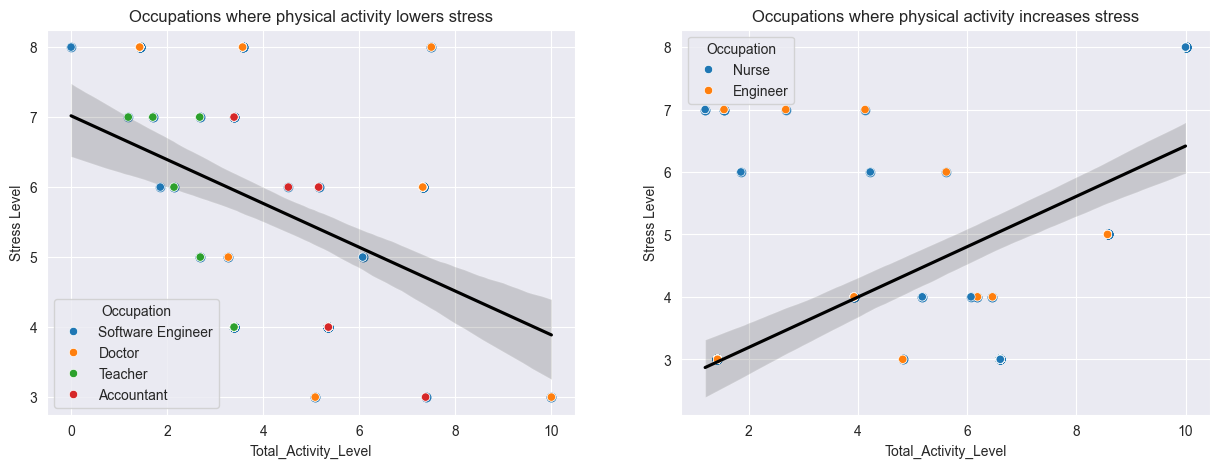

In [130]:
negative_correlation = ["Software Engineer", "Doctor", "Teacher", "Accountant"]
positive_correlation = ["Nurse", "Engineer"]

fix, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# sns.kdeplot(df_agg[df_agg['Occupation'].isin(negative_correlation)], x="Total_Activity_Level", y="Stress Level", ax=ax1, hue="Occupation")
sns.regplot(df_agg[df_agg['Occupation'].isin(negative_correlation)], x="Total_Activity_Level", y="Stress Level", ax=ax1, line_kws={"color": "black"})
sns.scatterplot(df_agg[df_agg['Occupation'].isin(negative_correlation)], x="Total_Activity_Level", y="Stress Level", ax=ax1, hue="Occupation")
ax1.set_title("Occupations where physical activity lowers stress")

# sns.kdeplot(df_agg[df_agg['Occupation'].isin(positive_correlation)], x="Total_Activity_Level", y="Stress Level", ax=ax2, hue="Occupation")
sns.regplot(df_agg[df_agg['Occupation'].isin(positive_correlation)], x="Total_Activity_Level", y="Stress Level", ax=ax2, line_kws={"color": "black"})
sns.scatterplot(df_agg[df_agg['Occupation'].isin(positive_correlation)], x="Total_Activity_Level", y="Stress Level", ax=ax2, hue="Occupation")
ax2.set_title("Occupations where physical activity increases stress")


### Final Observations
- Looking at the scatter plots of the two sets of occupations, it looks like the two occupations with a positive correlation between stress and total activity levels are likely caused by outliers.
- This indicates that although the 3 clusters I described early appear in aggregate, the hypothesis that they may be linked to occupation is not shown in this data.

In [131]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(IMG_DIR+'/Stress_Level_by_Cluster.png')

# Notebook Summary

## Stress vs. Activity Analysis
This project explores the relationship between total activity levels and self-reported stress across different occupations. The goal was to identify whether higher activity is associated with increased stress and whether occupation plays a meaningful role in that relationship.

The analysis includes:
- Data cleaning and occupation-level filtering
- Exploratory data analysis (EDA)
- Correlation analysis
- K-means clustering to identify patterns in activity and stress


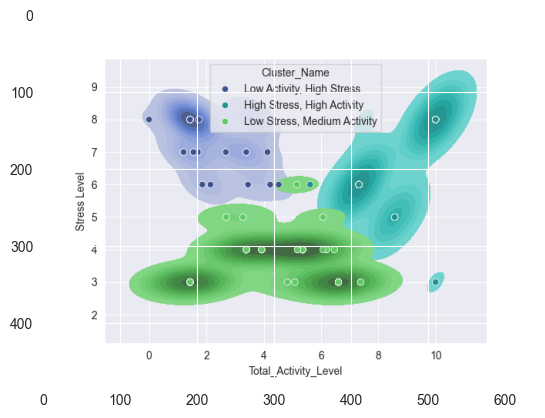

In [132]:
plt.imshow(img);

Three distinct clusters were identified when analyzing the full dataset, suggesting meaningful population-level groupings. However, when the data were examined within individual occupations, these cluster patterns were not consistently reproduced. In several cases, apparent correlations appeared to be influenced by outliers rather than stable occupation-level trends.

These results suggest that the relationship between activity and stress is more evident at the aggregate level than within specific occupations. Several occupations were also excluded due to insufficient sample sizes, limiting subgroup analysis.

This project demonstrates exploratory analysis, clustering, and the importance of validating aggregate patterns at the subgroup level when working with real-world data.

## Final Observations
Looking at the scatter plots of the two sets of occupations, it looks like the two occupations with a positive correlation between stress and total activity levels are likely caused by outliers.
This indicates that although the three clusters I described early appear in aggregate, the hypothesis that they may be linked to occupation is not shown in this data.

## Actionable Observations
Efforts to improve sleep duration and sleep quality have a huge effect on overall health.


Tools: Python, Pandas, Matplotlib/Seaborn, Scikit-learn, Jupyter